# **Consumer Complaint Database — Analisis Sentimen**

**Dataset:** Consumer Financial Protection Bureau (CFPB) Complaints  
**Topik:** Analisis Sentimen & Eksplorasi Keluhan Konsumen

### Pertanyaan Analisis
1. Keluhan apa yang paling sering muncul?
2. Apakah jumlah keluhan meningkat atau menurun dari waktu ke waktu?
3. Jenis masalah apa yang sering dikeluhkan pelanggan?
4. Bagaimana sentimen narasi keluhan konsumen? (Negatif / Positif)

> Notebook ini menggunakan **Apache Spark** untuk memproses dataset besar (~5.5 GB, ~9.5 juta baris).

# **Cell 1: Install Dependencies**

Install semua library yang diperlukan untuk project Big Data Sentiment Analysis.

In [ ]:

import os, sys
from pathlib import Path

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

if sys.platform == 'win32':
    import urllib.request
    _hh = (Path.home() / 'hadoop' / 'hadoop-3.3.4').resolve()
    _bin = _hh / 'bin'
    _bin.mkdir(parents=True, exist_ok=True)
    _url = 'https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.5/bin'
    for _f in ('winutils.exe', 'hadoop.dll'):
        _t = _bin / _f
        if not _t.exists():
            urllib.request.urlretrieve(f'{_url}/{_f}', _t)
    os.environ['HADOOP_HOME'] = str(_hh)
    os.environ['hadoop.home.dir'] = str(_hh)
    os.environ['PATH'] = str(_bin) + os.pathsep + os.environ.get('PATH', '')
    print(f' Hadoop Windows: {_hh}')

# Install PySpark
!pip install pyspark==3.4.1 -q

# Install visualisasi & NLP
!pip install wordcloud vaderSentiment -q

print(" Semua dependencies berhasil diinstall")

 Hadoop Windows: C:\Users\PC\hadoop\hadoop-3.3.4



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


 Semua dependencies berhasil diinstall



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Cell 2: Setup Project + Init Spark**

Inisialisasi Spark Session dengan konfigurasi untuk Big Data processing.

> **Catatan:** Jika menjalankan di Google Colab, uncomment baris `drive.mount()` dan sesuaikan `DATA_PATH`.

In [24]:
import os
import sys
import urllib.request
from pathlib import Path

# 1. Import komponen utama dari PySpark Functions & Types
from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType, StringType

# 2. Import modul Python fungsi clean_text dan timer
import re
import time

# 3. Import untuk  visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


_hadoop_java_opts = ''
if sys.platform == 'win32':
    hadoop_home = (Path.home() / 'hadoop' / 'hadoop-3.3.4').resolve()
    bin_dir = hadoop_home / 'bin'
    bin_dir.mkdir(parents=True, exist_ok=True)
    _winutils_url = 'https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.5/bin'
    for fname in ('winutils.exe', 'hadoop.dll'):
        target = bin_dir / fname
        if not target.exists():
            print(f' Mengunduh {fname} (sekali saja)...')
            urllib.request.urlretrieve(f'{_winutils_url}/{fname}', target)
    hadoop_home_str = str(hadoop_home)
    hadoop_home_java = hadoop_home.as_posix()
    os.environ['HADOOP_HOME'] = hadoop_home_str
    os.environ['hadoop.home.dir'] = hadoop_home_str
    os.environ['PATH'] = str(bin_dir) + os.pathsep + os.environ.get('PATH', '')
    _hadoop_java_opts = f'-Dhadoop.home.dir={hadoop_home_java}'
    _hadoop_home_spark = hadoop_home_java
else:
    _hadoop_home_spark = ''

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
_python_exec = sys.executable.replace('\\', '/')

# KONFIGURASI PATH
DATA_PATH = r'C:\Users\PC\Downloads\Tubes BigData\complaints.csv'

PROJECT_DIR = os.path.join(os.path.dirname(DATA_PATH), 'consumer_complaint_project')
CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
MODEL_DIR = f'{PROJECT_DIR}/models'
VIZ_DIR = f'{PROJECT_DIR}/visualizations'

for folder in [PROJECT_DIR, CHECKPOINT_DIR, MODEL_DIR, VIZ_DIR]:
    os.makedirs(folder, exist_ok=True)


print(f" Project dir : {PROJECT_DIR}")
print(f" Dataset path: {DATA_PATH}")

# Inisialisasi Spark Session 
from pyspark.sql import SparkSession

_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .appName("ConsumerComplaintSentimentAnalysis") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "8") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "false") \
    .config("spark.driver.extraJavaOptions", _hadoop_java_opts) \
    .config("spark.executor.extraJavaOptions", _hadoop_java_opts) \
    .config("spark.hadoop.hadoop.home.dir", _hadoop_home_spark) \
    .config("spark.pyspark.python", _python_exec) \
    .config("spark.pyspark.driver.python", _python_exec) \
    .config("spark.network.timeout", "3600s") \
    .config("spark.sql.broadcastTimeout", "3600s") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("WARN")

if sys.platform == 'win32':
    try:
        spark.range(1).coalesce(1).write.mode('overwrite').parquet(f'{CHECKPOINT_DIR}/_hadoop_test')
        print(' Hadoop Windows: parquet write OK')
    except Exception as _e:
        raise RuntimeError(
            'Parquet write gagal di Windows. Kernel → Restart, lalu jalankan Cell 1 → 2 → 3 dari awal.'
        ) from _e

print(f" Spark Session initialized")
print(f"   spark.sql.shuffle.partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"   spark.default.parallelism   : {spark.conf.get('spark.default.parallelism')}")

 Project dir : C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project
 Dataset path: C:\Users\PC\Downloads\Tubes BigData\complaints.csv
 Hadoop Windows: parquet write OK
 Spark Session initialized
   spark.sql.shuffle.partitions: 8
   spark.default.parallelism   : 8


# **Cell 3: Load Dataset**

Load dataset Consumer Complaint ke Spark DataFrame dengan optimisasi `.cache()` dan `.repartition()`.

In [3]:
import time
import os
from pyspark import StorageLevel
from pyspark.sql.functions import col, to_date, year, month, length

DATA_PATH = r'C:\Users\PC\Downloads\Tubes BigData\complaints.csv'
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH}")

print(" Loading Consumer Complaint Database with Spark...")
print(f"   Reading from: {DATA_PATH}")
t0 = time.time()

# 1. BACA DATA 
df_raw = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=True,
    quote='"',
    escape='"',
    multiLine=True
)

# 2. SELEKSI KOLOM & RENAME LANGSUNG 

df_processed = df_raw.select(
    col("Date received").alias("date_received"),
    col("Product"),
    col("Sub-product").alias("sub_product"),
    col("Issue"),
    col("Sub-issue").alias("sub_issue"),
    col("Consumer complaint narrative").alias("narrative"),
    col("Company public response").alias("company_public_response"),
    col("Company"),
    col("State"),
    col("ZIP code").alias("zip_code"),
    col("Consumer consent provided?").alias("consumer_consent"),
    col("Submitted via").alias("submitted_via"),
    col("Date sent to company").alias("date_sent"),
    col("Company response to consumer").alias("company_response"),
    col("Timely response?").alias("timely_response"),
    col("Consumer disputed?").alias("consumer_disputed"),
    col("Complaint ID").alias("complaint_id")
)

# 3. FILTER BARIS KOSONG DI AWAL 

df_narrative = df_processed.filter(
    col("narrative").isNotNull() & (length(col("narrative")) > 0)
)

# 4. PARSE TANGGAL & TAMBAHKAN KOLOM 

df_final = df_narrative \
    .withColumn("date_received", to_date(col("date_received"), "yyyy-MM-dd")) \
    .withColumn("year", year(col("date_received"))) \
    .withColumn("month", month(col("date_received"))) \
    .withColumn("narrative_length", length(col("narrative")))

# 5. OPTIMISASI BIG DATA 

df_final = df_final.repartition(8).persist(StorageLevel.MEMORY_AND_DISK)

total_count = df_final.count()
load_time = time.time() - t0

print(f"\n Dataset loaded in {load_time:.1f}s")
print(f"   • Total complaints with narrative: {total_count:,} rows")
print(f"   • Partitions                     : {df_final.rdd.getNumPartitions()}")
print(f"\n Schema:")
df_final.printSchema()

# Preview data
df_final.select("date_received", "Product", "Issue", "Company", "narrative").show(5, truncate=80)

df = df_final

# Save checkpoint
try:
    df.write.mode('overwrite').parquet(f'{CHECKPOINT_DIR}/df_raw.parquet')
    print(f"\n Checkpoint saved to {CHECKPOINT_DIR}/df_raw.parquet")
except Exception as e:
    print(f"\n Checkpoint parquet dilewati: {e}")
    print("   df sudah di-cache — lanjutkan cell berikutnya.")

 Loading Consumer Complaint Database with Spark...
   Reading from: C:\Users\PC\Downloads\Tubes BigData\complaints.csv

 Dataset loaded in 92.3s
   • Total complaints with narrative: 2,950,442 rows
   • Partitions                     : 8

 Schema:
root
 |-- date_received: date (nullable = true)
 |-- Product: string (nullable = true)
 |-- sub_product: string (nullable = true)
 |-- Issue: string (nullable = true)
 |-- sub_issue: string (nullable = true)
 |-- narrative: string (nullable = true)
 |-- company_public_response: string (nullable = true)
 |-- Company: string (nullable = true)
 |-- State: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- consumer_consent: string (nullable = true)
 |-- submitted_via: string (nullable = true)
 |-- date_sent: date (nullable = true)
 |-- company_response: string (nullable = true)
 |-- timely_response: string (nullable = true)
 |-- consumer_disputed: string (nullable = true)
 |-- complaint_id: integer (nullable = true)
 |-- year: 

# **Cell 3b: Cek Missing Values**

Analisis jumlah null per kolom dan total baris yang mengandung setidaknya satu nilai null.

In [4]:
from functools import reduce
from pyspark.sql import functions as F

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show(truncate=False)

rows_with_null = df.filter(
    reduce(
        lambda a, b: a | b,
        [F.col(c).isNull() for c in df.columns]
    )
).count()

print("Jumlah baris yang mengandung null:", rows_with_null)

+-------------+-------+-----------+-----+---------+---------+-----------------------+-------+-----+--------+----------------+-------------+---------+----------------+---------------+-----------------+------------+----+-----+----------------+
|date_received|Product|sub_product|Issue|sub_issue|narrative|company_public_response|Company|State|zip_code|consumer_consent|submitted_via|date_sent|company_response|timely_response|consumer_disputed|complaint_id|year|month|narrative_length|
+-------------+-------+-----------+-----+---------+---------+-----------------------+-------+-----+--------+----------------+-------------+---------+----------------+---------------+-----------------+------------+----+-----+----------------+
|0            |0      |52206      |0    |296404   |0        |1364597                |0      |10878|0       |0               |0            |0        |9               |0              |0                |0           |0   |0    |0               |
+-------------+-------+---------

In [5]:
from functools import reduce
from pyspark.sql import functions as F

null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show(truncate=False)

rows_with_null = df.filter(
    reduce(
        lambda a, b: a | b,
        [F.col(c).isNull() for c in df.columns]
    )    
).count()

print("Jumlah baris yang mengandung null:", rows_with_null)

+-------------+-------+-----------+-----+---------+---------+-----------------------+-------+-----+--------+----------------+-------------+---------+----------------+---------------+-----------------+------------+----+-----+----------------+
|date_received|Product|sub_product|Issue|sub_issue|narrative|company_public_response|Company|State|zip_code|consumer_consent|submitted_via|date_sent|company_response|timely_response|consumer_disputed|complaint_id|year|month|narrative_length|
+-------------+-------+-----------+-----+---------+---------+-----------------------+-------+-----+--------+----------------+-------------+---------+----------------+---------------+-----------------+------------+----+-----+----------------+
|0            |0      |52206      |0    |296404   |0        |1364597                |0      |10878|0       |0               |0            |0        |9               |0              |0                |0           |0   |0    |0               |
+-------------+-------+---------

In [6]:
from pyspark.sql import functions as F

count_lt_10 = df.filter(
    F.col("narrative").isNotNull() & (F.length(F.col("narrative")) < 10)
).count()

print("Jumlah narrative < 10 karakter:", count_lt_10)

df.filter(
    F.col("narrative").isNotNull() & (F.length(F.col("narrative")) < 10)
).select("narrative", "narrative_length").show(20, truncate=False)

Jumlah narrative < 10 karakter: 15
+---------+----------------+
|narrative|narrative_length|
+---------+----------------+
|Okay     |4               |
|Not items|9               |
|is not me|9               |
|No help  |7               |
|No help  |7               |
|No help  |7               |
|Old debt |8               |
|Paid debt|9               |
|Fraud    |5               |
|XXXX XXXX|9               |
|fradulent|9               |
|This week|9               |
|On credit|9               |
|XXXX     |4               |
|Not sure |8               |
+---------+----------------+



# **Cell 4: EDA — Keluhan Paling Sering Muncul**

**Pertanyaan 1:** Keluhan apa yang paling sering muncul?  
Analisis frekuensi berdasarkan **Product**, **Issue**, **Company**, dan **State**.

 TOP 10 PRODUK KELUHAN:
+----------------------------------------------------------------------------+-------+
|Product                                                                     |count  |
+----------------------------------------------------------------------------+-------+
|Credit reporting or other personal consumer reports                         |1067111|
|Credit reporting, credit repair services, or other personal consumer reports|807281 |
|Debt collection                                                             |333466 |
|Checking or savings account                                                 |139434 |
|Mortgage                                                                    |129873 |
|Credit card or prepaid card                                                 |108667 |
|Money transfer, virtual currency, or money service                          |96621  |
|Credit card                                                                 |79862  |
|Student loan      

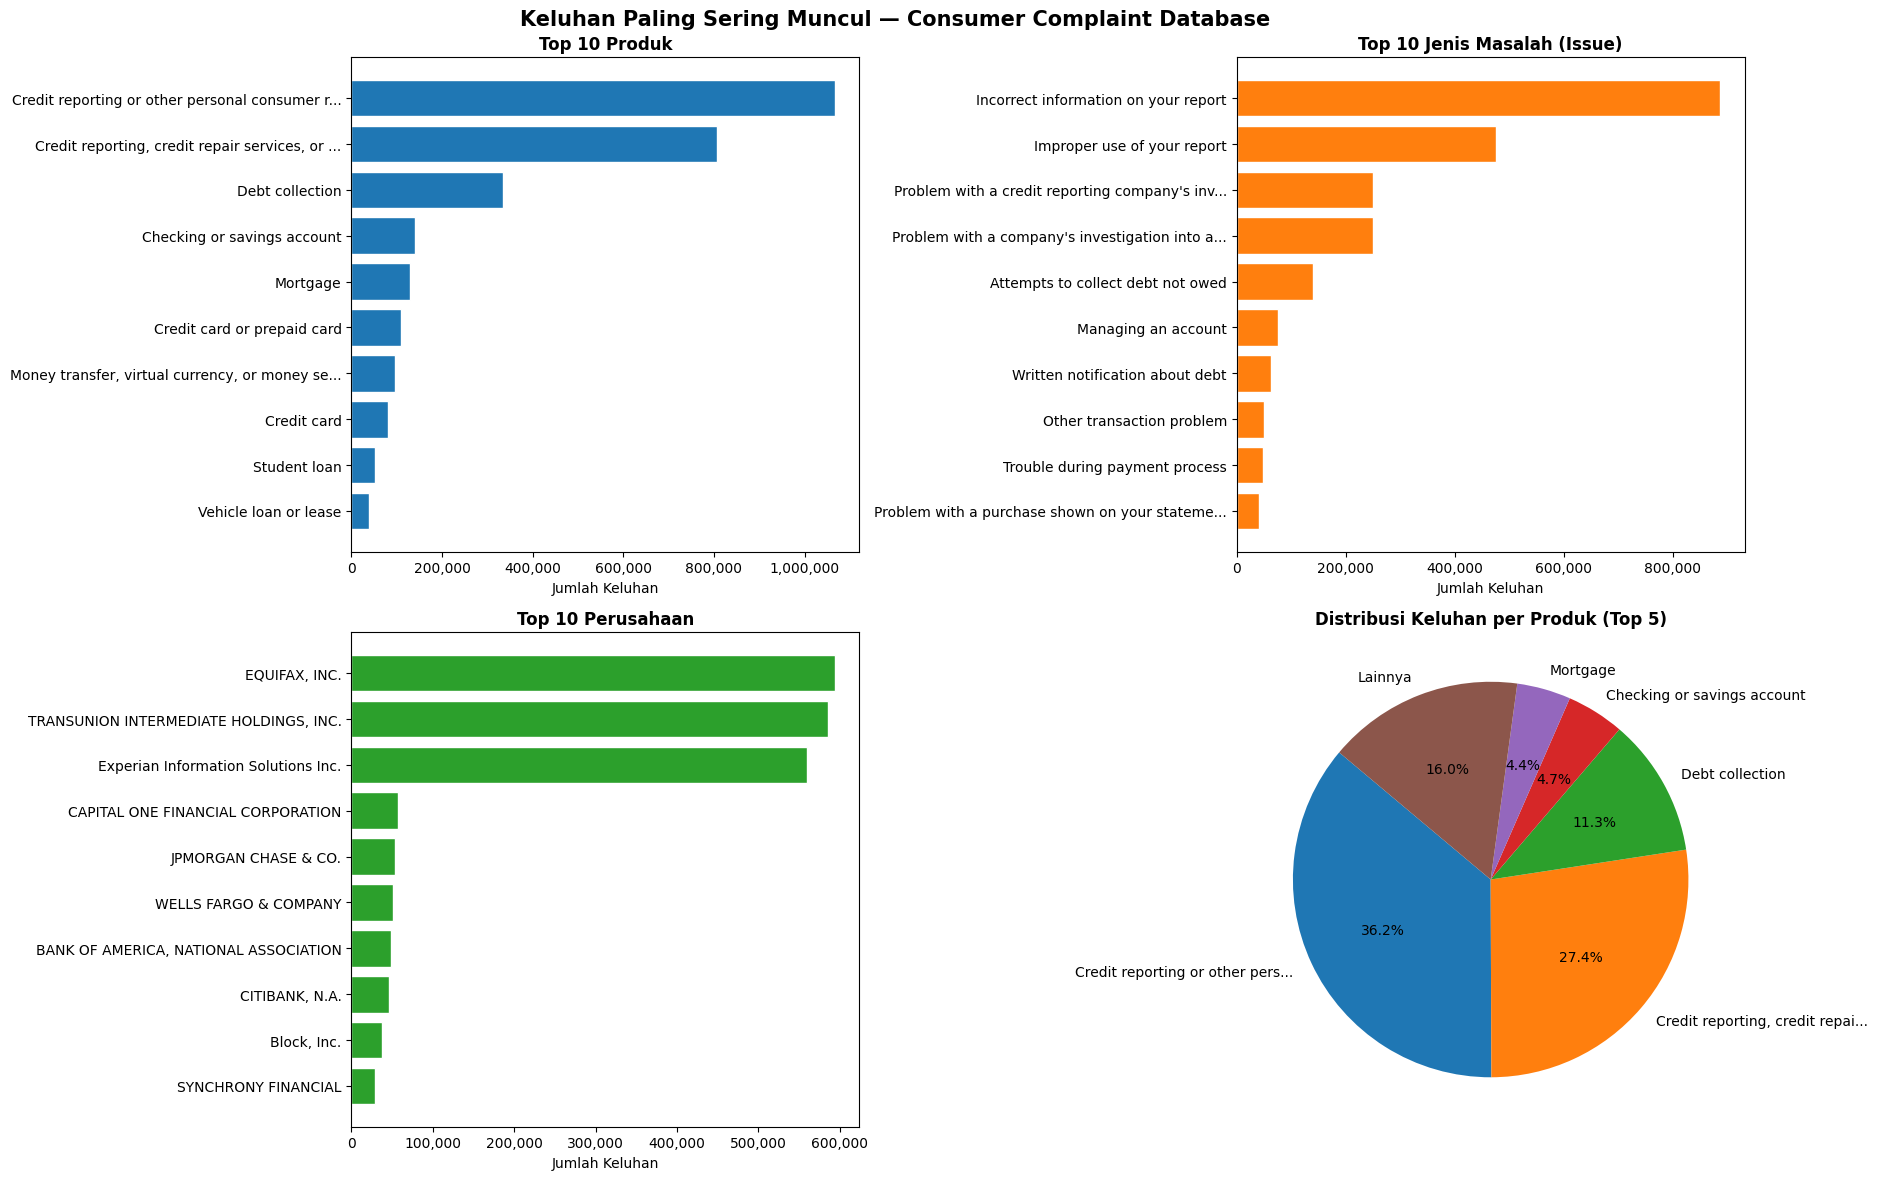

 Plot saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/visualizations/01_top_complaints.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.sql import functions as F

# 1. Top Products 
print(" TOP 10 PRODUK KELUHAN:")
top_products = df.groupBy("Product").count().orderBy(F.desc("count")).limit(10)
top_products.show(truncate=False)
top_products_pd = top_products.toPandas()

# 2. Top Issues 
print("\n TOP 10 JENIS MASALAH (ISSUE):")
top_issues = df.groupBy("Issue").count().orderBy(F.desc("count")).limit(10)
top_issues.show(truncate=False)
top_issues_pd = top_issues.toPandas()

# 3. Top Companies 
print("\n TOP 10 PERUSAHAAN DENGAN KELUHAN TERBANYAK:")
top_companies = df.groupBy("Company").count().orderBy(F.desc("count")).limit(10)
top_companies.show(truncate=False)
top_companies_pd = top_companies.toPandas()

# 4. Top States 
print("\n TOP 10 NEGARA BAGIAN (STATE):")
top_states = df.filter(col("State").isNotNull()) \
    .groupBy("State").count().orderBy(F.desc("count")).limit(10)
top_states.show(truncate=False)

# Visualisasi 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Keluhan Paling Sering Muncul — Consumer Complaint Database', fontsize=15, fontweight='bold')

def plot_horizontal_bar(ax, data, title, color):
    labels = [str(x)[:45] + '...' if len(str(x)) > 45 else str(x) for x in data.iloc[:, 0]]
    ax.barh(labels, data['count'], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Jumlah Keluhan')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plot_horizontal_bar(axes[0, 0], top_products_pd, 'Top 10 Produk', '#1f77b4')
plot_horizontal_bar(axes[0, 1], top_issues_pd, 'Top 10 Jenis Masalah (Issue)', '#ff7f0e')
plot_horizontal_bar(axes[1, 0], top_companies_pd, 'Top 10 Perusahaan', '#2ca02c')

# Pie chart distribusi produk top 5
top5 = top_products_pd.head(5)
other_count = total_count - top5['count'].sum()
pie_labels = list(top5['Product'].apply(lambda x: x[:30] + '...' if len(x) > 30 else x)) + ['Lainnya']
pie_values = list(top5['count']) + [other_count]
axes[1, 1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140)
axes[1, 1].set_title('Distribusi Keluhan per Produk (Top 5)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/01_top_complaints.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Plot saved to {VIZ_DIR}/01_top_complaints.png")

# **Cell 5: EDA — Tren Keluhan dari Waktu ke Waktu**

**Pertanyaan 2:** Apakah jumlah keluhan meningkat atau menurun dari waktu ke waktu?  
Analisis tren bulanan dan tahunan jumlah keluhan.

 TREN KELUHAN BULANAN:
+----------+---------------+
|year_month|complaint_count|
+----------+---------------+
|2015-03   |2377           |
|2015-04   |5379           |
|2015-05   |5644           |
|2015-06   |5905           |
|2015-07   |6630           |
|2015-08   |6453           |
|2015-09   |5761           |
|2015-10   |6260           |
|2015-11   |5136           |
|2015-12   |5194           |
|2016-01   |5651           |
|2016-02   |5579           |
|2016-03   |6409           |
|2016-04   |6215           |
|2016-05   |6192           |
|2016-06   |6333           |
|2016-07   |6562           |
|2016-08   |7092           |
|2016-09   |7488           |
|2016-10   |7545           |
|2016-11   |6142           |
|2016-12   |6587           |
|2017-01   |9475           |
|2017-02   |7658           |
|2017-03   |8467           |
|2017-04   |8540           |
|2017-05   |9696           |
|2017-06   |9175           |
|2017-07   |10020          |
|2017-08   |10307          |
|2017-09   |13457   

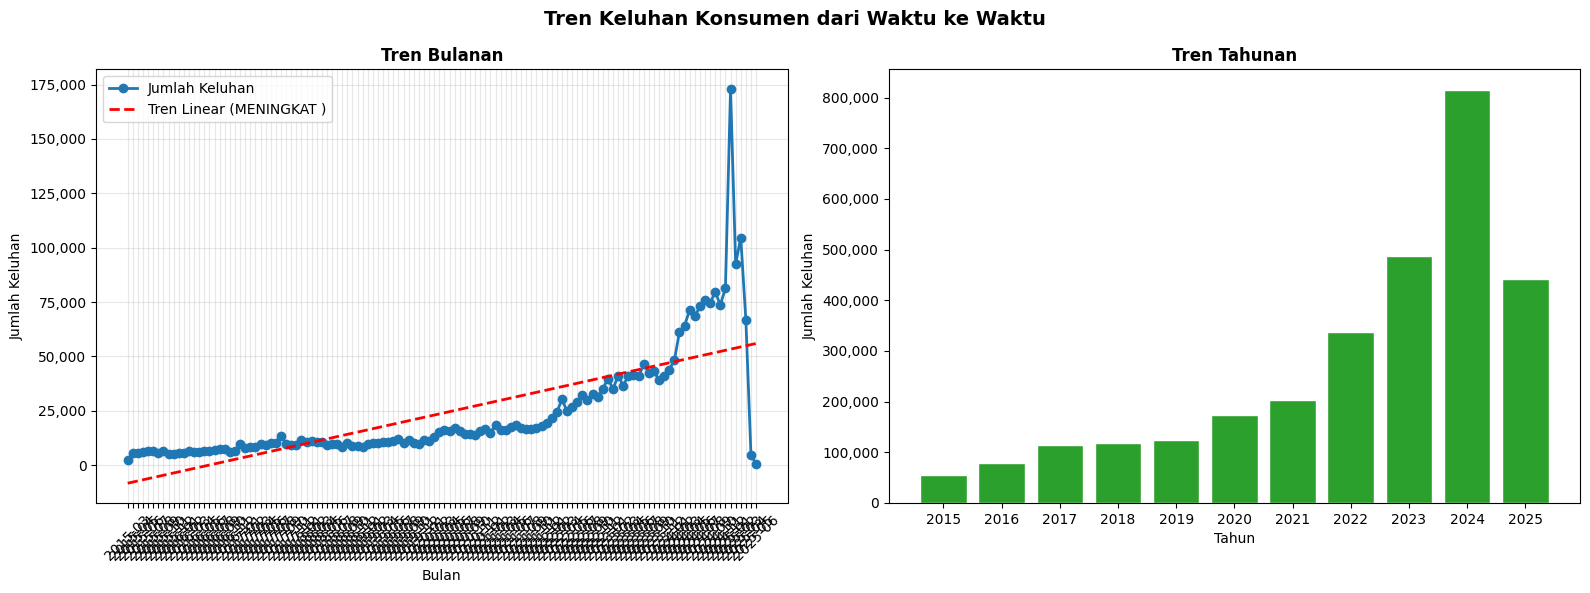

 Plot saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/visualizations/02_complaint_trend.png


In [8]:
from pyspark.sql.functions import date_format, count, col
import numpy as np

# Tren Bulanan 
monthly_trend = df \
    .filter(col("date_received").isNotNull()) \
    .groupBy(date_format(col("date_received"), "yyyy-MM").alias("year_month")) \
    .agg(count("*").alias("complaint_count")) \
    .orderBy("year_month")

print(" TREN KELUHAN BULANAN:")
monthly_trend.show(50, truncate=False)
monthly_pd = monthly_trend.toPandas()

# Tren Tahunan
yearly_trend = df \
    .filter(col("year").isNotNull()) \
    .groupBy("year").count().orderBy("year")

print("\n TREN KELUHAN TAHUNAN:")
yearly_trend.show()
yearly_pd = yearly_trend.toPandas()

# Analisis Tren (Linear Regression sederhana) 
x = np.arange(len(monthly_pd))
y = monthly_pd['complaint_count'].values
slope, intercept = np.polyfit(x, y, 1)
trend_direction = "MENINGKAT " if slope > 0 else "MENURUN "
avg_monthly = y.mean()
pct_change = ((y[-1] - y[0]) / y[0]) * 100 if y[0] > 0 else 0

print(f"\n{'='*60}")
print(f"ANALISIS TREN KELUHAN")
print(f"{'='*60}")
print(f"  Periode data        : {monthly_pd['year_month'].iloc[0]} s/d {monthly_pd['year_month'].iloc[-1]}")
print(f"  Rata-rata per bulan : {avg_monthly:,.0f} keluhan")
print(f"  Bulan pertama       : {y[0]:,} keluhan")
print(f"  Bulan terakhir      : {y[-1]:,} keluhan")
print(f"  Perubahan total     : {pct_change:+.1f}%")
print(f"  Arah tren           : {trend_direction}")
print(f"  Slope (keluhan/bln) : {slope:+,.0f}")
print(f"{'='*60}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tren Keluhan Konsumen dari Waktu ke Waktu', fontsize=14, fontweight='bold')

# Line chart bulanan
axes[0].plot(monthly_pd['year_month'], monthly_pd['complaint_count'], marker='o', linewidth=2, color='#1f77b4', label='Jumlah Keluhan')
trend_line = slope * x + intercept
axes[0].plot(monthly_pd['year_month'], trend_line, '--', color='red', linewidth=2, label=f'Tren Linear ({trend_direction})')
axes[0].set_title('Tren Bulanan', fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Keluhan')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart tahunan
axes[1].bar(yearly_pd['year'].astype(str), yearly_pd['count'], color='#2ca02c', edgecolor='white')
axes[1].set_title('Tren Tahunan', fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah Keluhan')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/02_complaint_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Plot saved to {VIZ_DIR}/02_complaint_trend.png")

# **Cell 6: EDA — Jenis Masalah yang Sering Dikeluhkan**

**Pertanyaan 3:** Jenis masalah apa yang sering dikeluhkan pelanggan?  
Analisis mendalam pada **Issue**, **Sub-issue**, dan kombinasi **Product + Issue**.

 TOP 15 SUB-ISSUE:
+--------------------------------------------------------------------------------+------+
|sub_issue                                                                       |count |
+--------------------------------------------------------------------------------+------+
|Information belongs to someone else                                             |501549|
|Reporting company used your report improperly                                   |348513|
|Their investigation did not fix an error on your report                         |309505|
|Account status incorrect                                                        |140264|
|Account information incorrect                                                   |137282|
|Credit inquiries on your report that you don't recognize                        |122649|
|Investigation took more than 30 days                                            |89243 |
|Debt is not yours                                                               

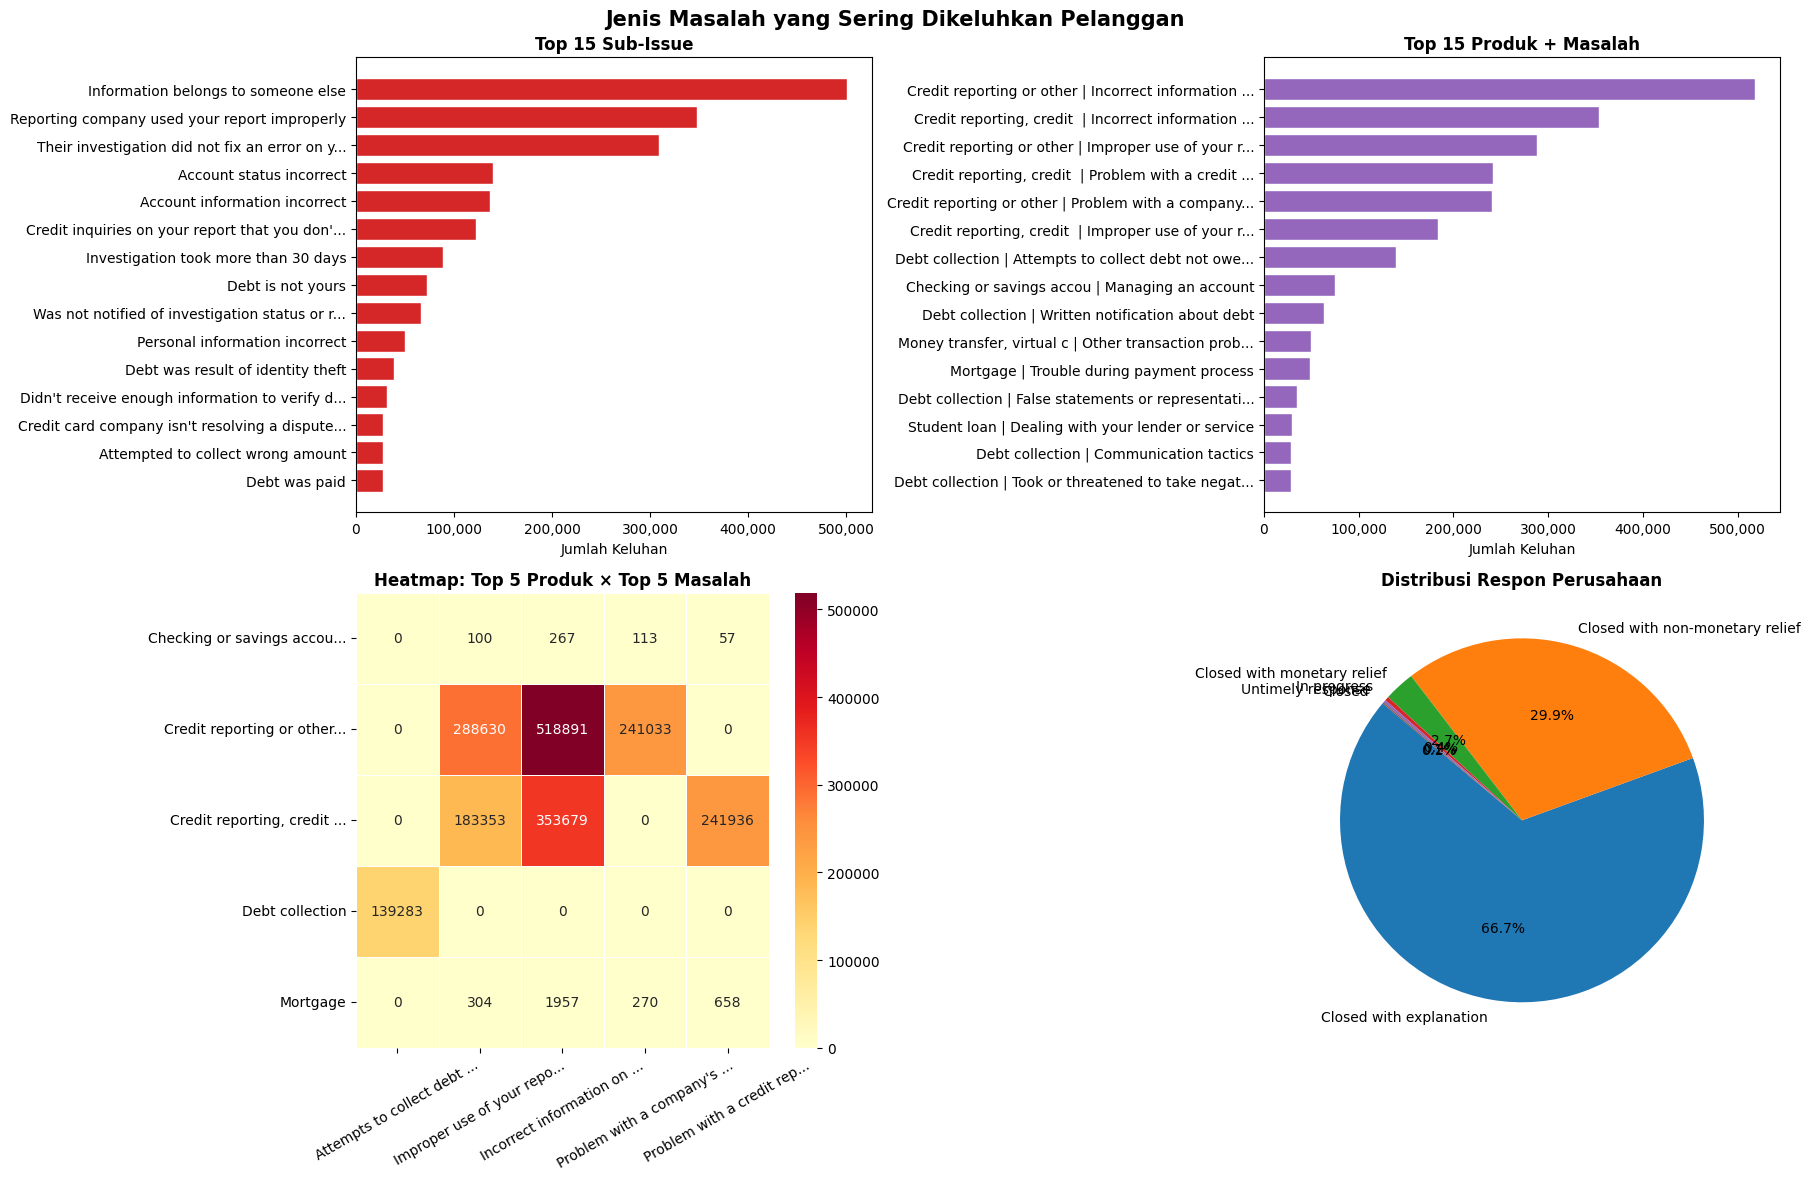

 Plot saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/visualizations/03_issue_analysis.png


In [9]:
#   Top Sub-issues  
print(" TOP 15 SUB-ISSUE:")
top_sub_issues = df.filter(col("sub_issue").isNotNull()) \
    .groupBy("sub_issue").count().orderBy(F.desc("count")).limit(15)
top_sub_issues.show(truncate=False)
top_sub_issues_pd = top_sub_issues.toPandas()

#   Kombinasi Product + Issue  
print("\n TOP 15 KOMBINASI PRODUK + MASALAH:")
product_issue = df.groupBy("Product", "Issue").count().orderBy(F.desc("count")).limit(15)
product_issue.show(truncate=False)
product_issue_pd = product_issue.toPandas()
product_issue_pd['combo'] = product_issue_pd['Product'].str[:25] + ' | ' + product_issue_pd['Issue'].str[:35]

#   Company Response Distribution  
print("\n DISTRIBUSI RESPON PERUSAHAAN:")
response_dist = df.filter(col("company_response").isNotNull()) \
    .groupBy("company_response").count().orderBy(F.desc("count"))
response_dist.show(truncate=False)
response_pd = response_dist.toPandas()

#   Visualisasi  
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Jenis Masalah yang Sering Dikeluhkan Pelanggan', fontsize=15, fontweight='bold')

plot_horizontal_bar(axes[0, 0], top_sub_issues_pd, 'Top 15 Sub-Issue', '#d62728')

# Plot combo Product + Issue
combo_labels = [str(x)[:50] + '...' if len(str(x)) > 50 else str(x) for x in product_issue_pd['combo']]
axes[0, 1].barh(combo_labels, product_issue_pd['count'], color='#9467bd', edgecolor='white')
axes[0, 1].set_title('Top 15 Produk + Masalah', fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Keluhan')
axes[0, 1].invert_yaxis()
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Heatmap: Top 5 Product x Top 5 Issue
top5_products = [r['Product'] for r in top_products.collect()[:5]]
top5_issues = [r['Issue'] for r in top_issues.collect()[:5]]
heatmap_data = df.filter(col("Product").isin(top5_products) & col("Issue").isin(top5_issues)) \
    .groupBy("Product", "Issue").count().toPandas()
pivot = heatmap_data.pivot(index='Product', columns='Issue', values='count').fillna(0)
pivot.index = [x[:25] + '...' if len(x) > 25 else x for x in pivot.index]
pivot.columns = [x[:25] + '...' if len(x) > 25 else x for x in pivot.columns]

import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1, 0], linewidths=0.5)
axes[1, 0].set_title('Heatmap: Top 5 Produk × Top 5 Masalah', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=30)

# Pie chart company response
axes[1, 1].pie(response_pd['count'], labels=response_pd['company_response'], autopct='%1.1f%%', startangle=140)
axes[1, 1].set_title('Distribusi Respon Perusahaan', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/03_issue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Plot saved to {VIZ_DIR}/03_issue_analysis.png")

# **Cell 7: EDA — Word Cloud & Top Words**

Visualisasi kata-kata yang paling sering muncul dalam narasi keluhan konsumen.

In [10]:
!pip install pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


⏳ Menghitung kata populer dari narasi keluhan (Optimized Distributed)...
✅ Selesai dalam 2.15 detik!

📊 TOP 20 KATA DALAM NARASI KELUHAN:
  credit               : 285,752
  account              : 207,515
  report               : 173,715
  information          : 172,997
  consumer             : 139,001
  reporting            : 131,772
  any                  : 120,386
  accounts             : 81,206
  usc                  : 73,243
  payment              : 67,604
  debt                 : 63,271
  section              : 58,731
  under                : 56,111
  agency               : 48,463
  please               : 48,330
  inaccurate           : 46,080
  act                  : 43,711
  company              : 43,381
  bank                 : 43,295
  balance              : 42,133


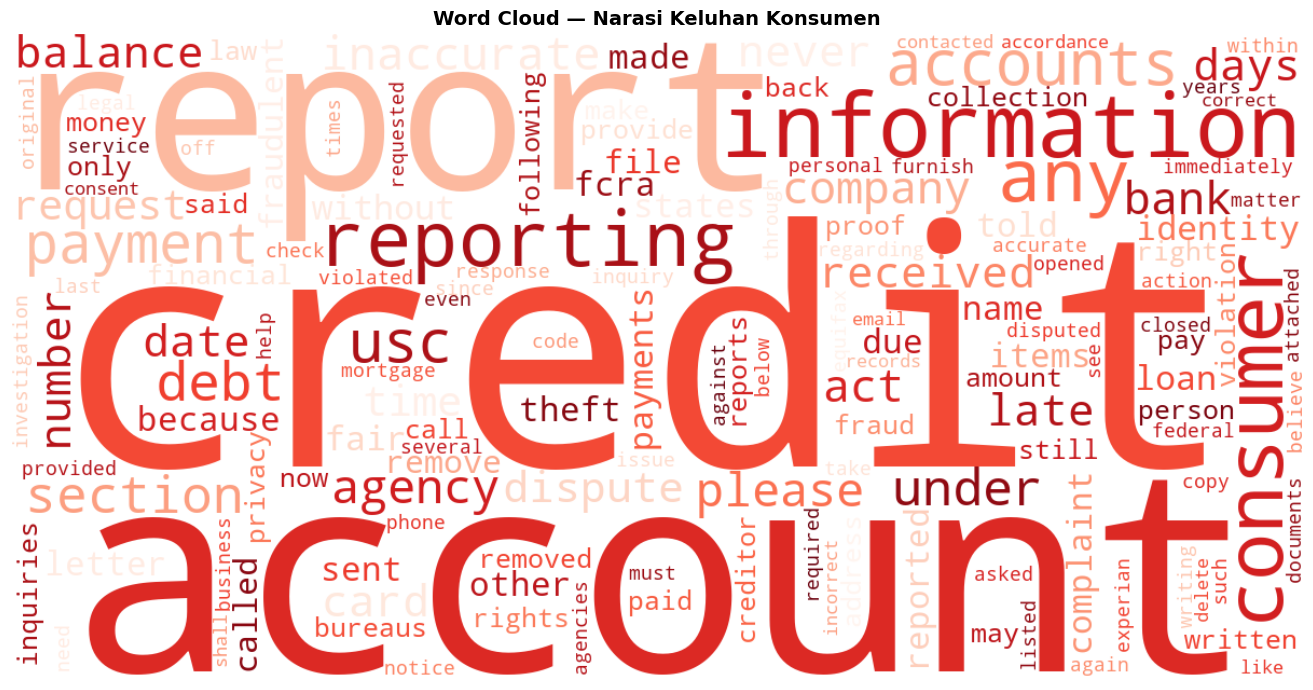

✅ Word cloud saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/visualizations/04_wordcloud.png


In [ ]:
import re
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from wordcloud import WordCloud
from pyspark.sql import functions as F
from pyspark.sql.functions import col, explode, split, lower, regexp_replace, length

# 1. STOPWORDS LIST
stopwords = {'xxxx','xxxxxxxx','the','a','an','and','or','but','in','on','at','to','for','of','with','is','was','it','this','that','i','my','you','your','we','they','have','had','be','are','not','so','as','if','by','from','its','he','she','do','did','will','would', 'could','should','been','has','her','his','their','our','what','which','who','when','how','all','just','also','more','very','can','about','up','out','no','me','him','them','then','than','one','there','these','those','into','over','after','get','got','s','am','been','being','were','does','didn','don','won','wouldn','couldn','shouldn','hasn','haven','hadn','doesn','wasn','weren','isn','aren','t','ve','re','ll','d','m','o','u'}

# 2. FILTER DATA UNTUK WORD CLOUD 
df_narrative = df.filter(col("narrative").isNotNull())

def get_top_words_spark(df_in, limit=150):

    df_sample = df_in.sample(withReplacement=False, fraction=0.05, seed=42)
    
    word_counts = df_sample \
        .select(regexp_replace(lower(col("narrative")), r'[^a-z\s]', '').alias("cleaned")) \
        .select(explode(split(col("cleaned"), r'\s+')).alias("word")) \
        .filter(length(col("word")) > 2) \
        .filter(~col("word").isin(stopwords)) \
        .groupBy("word").count() \
        .orderBy(F.desc("count")).limit(limit) \
        .toPandas()
        
    return dict(zip(word_counts['word'], word_counts['count'])) if not word_counts.empty else {"empty": 1}

print(" Menghitung kata populer dari narasi keluhan (Optimized Distributed)...")
t_wc = time.time()
freq_all = get_top_words_spark(df_narrative)
print(f" Selesai dalam {(time.time() - t_wc):.2f} detik!")

# Top 20 kata
top20 = sorted(freq_all.items(), key=lambda x: x[1], reverse=True)[:20]
print("\n TOP 20 KATA DALAM NARASI KELUHAN:")
for word, cnt in top20:
    print(f"  {word:20s} : {cnt:,}")

# 3. GENERATE WORD CLOUD VISUALIZATION
fig, ax = plt.subplots(figsize=(14, 7))
wc = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    colormap='Reds', 
    max_words=150
).generate_from_frequencies(freq_all)

ax.imshow(wc, interpolation='bilinear')
ax.set_title('Word Cloud — Narasi Keluhan Konsumen', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()

# Save Gambar
plt.savefig(f'{VIZ_DIR}/04_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Word cloud saved to {VIZ_DIR}/04_wordcloud.png")

# **Cell 8: Sentiment Labeling dengan VADER**

Karena dataset tidak memiliki label sentimen eksplisit, kita menggunakan **VADER Sentiment Analyzer** untuk memberi label pada narasi keluhan:
- **Negatif (0):** compound score < -0.05
- **Positif (1):** compound score > 0.05
- **Netral:** dihapus dari training set

 Menghitung sentimen VADER pada narasi keluhan...
   VADER sanity check compound=-0.778
   Narasi tersedia : 2,950,442
   Sample VADER    : 59,122 (2%)
✅ Sentiment labeling done in 0.7 min
   Total labeled samples: 56,552

 DISTRIBUSI SENTIMEN:
+-----+-----+
|label|count|
+-----+-----+
|  0.0|28680|
|  1.0|27872|
+-----+-----+



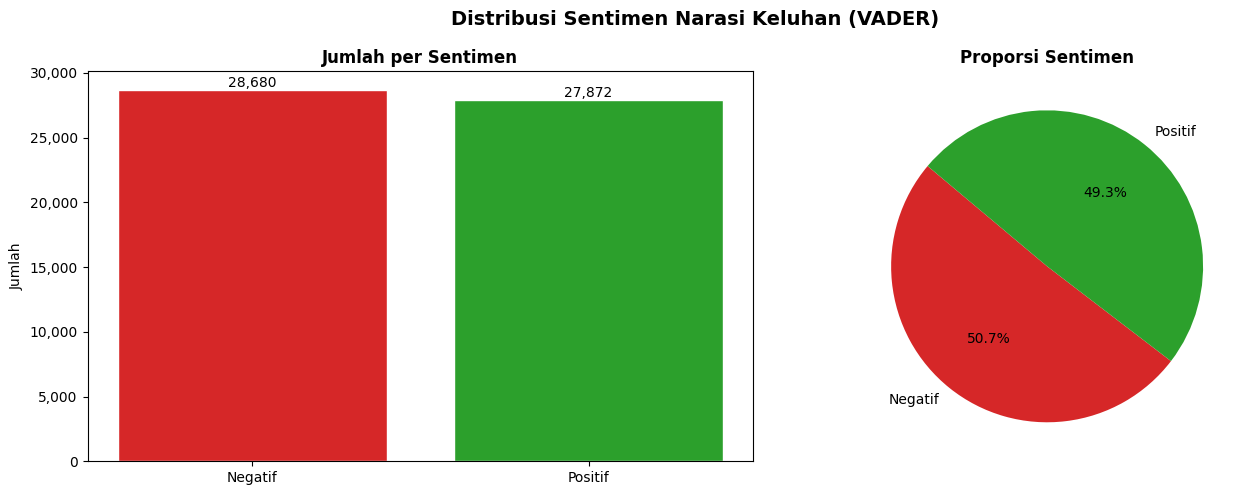


 Split: Train=45,472 | Test=11,080


In [ ]:

# 1. IMPORT SEMUA REQUISITE LIBRARIES 

import re
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql import functions as F
from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType, StringType


# 2. KONFIGURASI & GLOBAL ANALYZER (Mencegah Lemot/Timeout)


SENTIMENT_SAMPLE_FRACTION = 0.02

_vader_analyzer = SentimentIntensityAnalyzer()

# 3. DEFINISI FUNGSI DAN UDF

def get_sentiment_scores(text):
    try:
        if text is None:
            return (0.0, 0.0, 0.0, 0.0)

        text = str(text).strip()
        if len(text) < 5:
            return (0.0, 0.0, 0.0, 0.0)

        scores = _vader_analyzer.polarity_scores(text)
        return (
            float(scores["neg"]),
            float(scores["neu"]),
            float(scores["pos"]),
            float(scores["compound"]),
        )
    except Exception:
        return (0.0, 0.0, 0.0, 0.0)


def get_label(compound):
    if compound is None:
        return None

    if compound < -0.05:
        return 0.0

    if compound > 0.05:
        return 1.0

    return None


def clean_text(text):
    try:
        if text is None:
            return ""

        text = str(text).lower()

        # hapus html
        text = re.sub(r"<[^>]+>", " ", text)

        # hapus url
        text = re.sub(r"http\S+|www\S+", " ", text)

        # sisakan huruf
        text = re.sub(r"[^a-z\s]", " ", text)

        # rapikan spasi
        text = re.sub(r"\s+", " ", text).strip()

        return text

    except Exception:
        return ""

# Registrasi fungsi menjadi PySpark UDF
sentiment_udf = udf(
    get_sentiment_scores,
    "struct<neg:float,neu:float,pos:float,compound:float>"
)
label_udf = udf(get_label, FloatType())
clean_udf = udf(clean_text, StringType())



# 4. EKSEKUSI PIPELINE SENTIMEN

print(" Menghitung sentimen VADER pada narasi keluhan...")
_vader_check = _vader_analyzer.polarity_scores("I am very angry about this fraudulent charge")
print(f"   VADER sanity check compound={_vader_check['compound']:.3f}")
t0 = time.time()

if "df_narrative" not in globals():
    raise RuntimeError("df_narrative belum ada. Jalankan Cell tempat membaca data terlebih dahulu.")

narrative_total = df_narrative.count()
if narrative_total == 0:
    raise RuntimeError("df_narrative kosong. Jalankan cell pengisian data terlebih dahulu.")

df_for_sentiment = df_narrative.sample(
    withReplacement=False,
    fraction=SENTIMENT_SAMPLE_FRACTION,
    seed=42,
)
sample_count = df_for_sentiment.count()
print(f"   Narasi tersedia : {narrative_total:,}")
print(f"   Sample VADER    : {sample_count:,} ({SENTIMENT_SAMPLE_FRACTION*100:.0f}%)")

# Distribusikan ulang beban data ke 8 partisi agar pemrosesan paralel optimal
df_for_sentiment = df_for_sentiment.repartition(8)

df_sentiment = (
    df_for_sentiment
    .withColumn("cleaned_text", clean_udf(col("narrative")))
    .withColumn("sentiment", sentiment_udf(col("cleaned_text")))
    .withColumn("neg_score", col("sentiment.neg"))
    .withColumn("neu_score", col("sentiment.neu"))
    .withColumn("pos_score", col("sentiment.pos"))
    .withColumn("compound", col("sentiment.compound"))
    .withColumn("label", label_udf(col("compound")))
    .filter(col("label").isNotNull())
    .filter(F.length(col("cleaned_text")) > 0)
    .drop("sentiment")
)

df_sentiment = df_sentiment.cache()
sentiment_count = df_sentiment.count()

if sentiment_count == 0:
    raise RuntimeError(
        "Tidak ada sampel berlabel. Pastikan data tidak kosong setelah difilter."
    )

print(f" Sentiment labeling done in {(time.time()-t0)/60:.1f} min")
print(f"   Total labeled samples: {sentiment_count:,}")


# 5. DISTRIBUSI SENTIMEN & VISUALISASI

print("\n DISTRIBUSI SENTIMEN:")
df_sentiment.groupBy("label").count().orderBy("label").show()

sentiment_dist = (
    df_sentiment
    .groupBy("label")
    .count()
    .orderBy("label")
    .toPandas()
)

label_map = {0.0: "Negatif", 1.0: "Positif"}
sentiment_dist["label_name"] = sentiment_dist["label"].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Distribusi Sentimen Narasi Keluhan (VADER)",
    fontsize=14,
    fontweight="bold",
)

colors_sent = ["#d62728", "#2ca02c"]

axes[0].bar(
    sentiment_dist["label_name"],
    sentiment_dist["count"],
    color=colors_sent[: len(sentiment_dist)],
    edgecolor="white",
)
axes[0].set_title("Jumlah per Sentimen", fontweight="bold")
axes[0].set_ylabel("Jumlah")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

for idx, row in sentiment_dist.iterrows():
    axes[0].text(
        idx,
        row["count"],
        f"{int(row['count']):,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

axes[1].pie(
    sentiment_dist["count"],
    labels=sentiment_dist["label_name"],
    autopct="%1.1f%%",
    colors=colors_sent[: len(sentiment_dist)],
    startangle=140,
)
axes[1].set_title("Proporsi Sentimen", fontweight="bold")

plt.tight_layout()
 
plt.savefig(
    f"{VIZ_DIR}/05_sentiment_distribution.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# 6. TRAIN TEST SPLIT

train_df, test_df = df_sentiment.randomSplit([0.8, 0.2], seed=42)

train_df = train_df.repartition(8).cache()
test_df = test_df.repartition(8).cache()

train_count = train_df.count()
test_count = test_df.count()

print(f"\n Split: Train={train_count:,} | Test={test_count:,}")


# **Cell 9: Text Preprocessing + TF-IDF Pipeline**

Text cleaning, tokenisasi, stopword removal, dan ekstraksi fitur TF-IDF.

In [16]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.sql.functions import length

if "train_df" not in globals() or "test_df" not in globals():
    raise RuntimeError("train_df/test_df belum ada. Jalankan Cell 8 terlebih dahulu.")

train_df = train_df.filter(length(col("cleaned_text")) > 0)
test_df = test_df.filter(length(col("cleaned_text")) > 0)

train_count = train_df.count()
test_count = test_df.count()
if train_count == 0 or test_count == 0:
    raise RuntimeError(
        f"Data train/test kosong (train={train_count}, test={test_count}). "
        "Jalankan ulang Cell 8."
    )

print(f" TF-IDF input: Train={train_count:,} | Test={test_count:,}")

tokenizer = Tokenizer(inputCol="cleaned_text", outputCol="tokens")
stopwords_remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="raw_features", numFeatures=10000)
idf = IDF(inputCol="raw_features", outputCol="features", minDocFreq=2)

preprocessing_pipeline = Pipeline(stages=[tokenizer, stopwords_remover, hashing_tf, idf])

print(" Fitting TF-IDF pipeline...")
t0 = time.time()
preprocessing_model = preprocessing_pipeline.fit(train_df)
print(f" Pipeline fit done in {(time.time()-t0)/60:.1f} min")

df_train_features = preprocessing_model.transform(train_df)
df_test_features = preprocessing_model.transform(test_df)

print(f" Features extracted: Train={df_train_features.count():,}, Test={df_test_features.count():,}")

df_train_features.select("label", "features").write.mode('overwrite').parquet(f'{CHECKPOINT_DIR}/df_train_features.parquet')
df_test_features.select("label", "features").write.mode('overwrite').parquet(f'{CHECKPOINT_DIR}/df_test_features.parquet')
preprocessing_model.write().overwrite().save(f'{MODEL_DIR}/preprocessing_pipeline')
print(f" Checkpoint saved!")

 TF-IDF input: Train=45,472 | Test=11,080
 Fitting TF-IDF pipeline...
 Pipeline fit done in 0.0 min
 Features extracted: Train=45,472, Test=11,080
 Checkpoint saved!


# **Cell 10: Model 1 — TF-IDF + Logistic Regression**

Training dan evaluasi Logistic Regression dengan fitur TF-IDF.

Training Logistic Regression...
 Training done in 0.24 min
MODEL 1: TF-IDF + LOGISTIC REGRESSION
Accuracy : 0.8516 (85.16%)
F1-Score : 0.8516
AUC-ROC  : 0.9143
Time     : 0.24 min


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


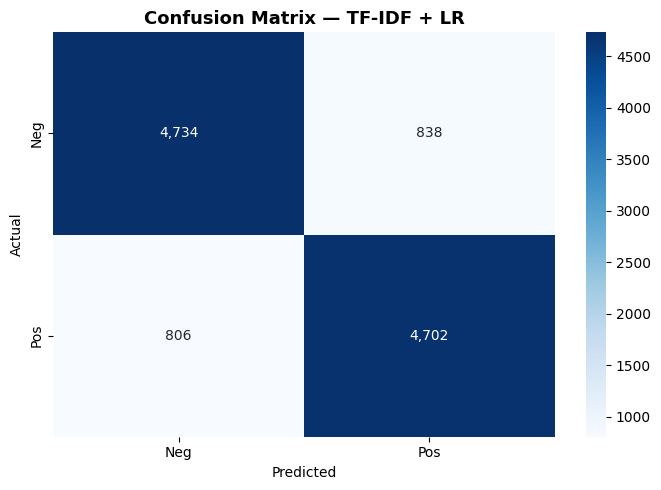

 Model saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/models


In [17]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.linalg import Vectors, VectorUDT, SparseVector
from pyspark.mllib.evaluation import MulticlassMetrics
import seaborn as sns

df_train_feat = spark.read.parquet(f'{CHECKPOINT_DIR}/df_train_features.parquet')
df_test_feat = spark.read.parquet(f'{CHECKPOINT_DIR}/df_test_features.parquet')

@udf(VectorUDT())
def correct_sparse_vector(vector):
    if vector is None or not isinstance(vector, SparseVector): return vector
    temp_dict = {}
    for idx, val in zip(vector.indices, vector.values):
        temp_dict[idx] = temp_dict.get(idx, 0.0) + val
    corrected = sorted(temp_dict.items())
    return Vectors.sparse(vector.size, np.array([i for i,_ in corrected], dtype=np.int32), np.array([v for _,v in corrected]))

df_train_feat = df_train_feat.withColumn("features", correct_sparse_vector(col("features")))
df_test_feat = df_test_feat.withColumn("features", correct_sparse_vector(col("features")))

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100, regParam=0.01, elasticNetParam=0.0, family="binomial")

print("Training Logistic Regression...")
t0 = time.time()
lr_model = lr.fit(df_train_feat)
t_lr = time.time() - t0
print(f" Training done in {t_lr/60:.2f} min")

lr_predictions = lr_model.transform(df_test_feat)

eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedFMeasure")
eval_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

lr_accuracy = eval_acc.evaluate(lr_predictions)
lr_f1 = eval_f1.evaluate(lr_predictions)
lr_auc = eval_auc.evaluate(lr_predictions)

print("MODEL 1: TF-IDF + LOGISTIC REGRESSION")
print(f"Accuracy : {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"F1-Score : {lr_f1:.4f}")
print(f"AUC-ROC  : {lr_auc:.4f}")
print(f"Time     : {t_lr/60:.2f} min")

lr_pred_rdd = lr_predictions.select(col("prediction").cast(FloatType()), col("label").cast(FloatType())).rdd.map(tuple)
metrics_lr = MulticlassMetrics(lr_pred_rdd)
cm_lr = metrics_lr.confusionMatrix().toArray().astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt=',', cmap='Blues', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'], ax=ax)
ax.set_title('Confusion Matrix — TF-IDF + LR', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/06_cm_tfidf_lr.png', dpi=150, bbox_inches='tight')
plt.show()

lr_model.write().overwrite().save(f'{MODEL_DIR}/logistic_regression_model')
import json
lr_results = {"model": "TF-IDF + LR", "accuracy": round(lr_accuracy, 4), "f1_score": round(lr_f1, 4), "auc_roc": round(lr_auc, 4), "training_time": round(t_lr/60, 2)}
with open(f'{CHECKPOINT_DIR}/lr_results.json', 'w') as f:
    json.dump(lr_results, f, indent=2)
print(f" Model saved to {MODEL_DIR}")

# **Cell 11: Model 2 — TF-IDF + Random Forest**

Training dan evaluasi Random Forest dengan fitur TF-IDF.

 Training Random Forest (100 trees, maxDepth=15)...
 Training done in 0.66 min
MODEL 2: TF-IDF + RANDOM FOREST
Accuracy : 0.7830 (78.30%)
F1-Score : 0.7828
AUC-ROC  : 0.8755
Time     : 0.66 min


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyspark\sql\context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


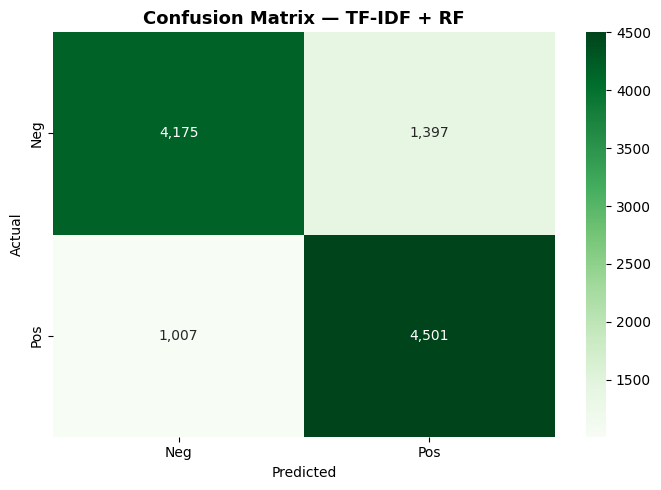

 Model saved to C:\Users\PC\Downloads\Tubes BigData\consumer_complaint_project/models


In [18]:
from pyspark.ml.classification import RandomForestClassifier

df_train_feat = spark.read.parquet(f'{CHECKPOINT_DIR}/df_train_features.parquet')
df_test_feat = spark.read.parquet(f'{CHECKPOINT_DIR}/df_test_features.parquet')
df_train_feat = df_train_feat.withColumn("features", correct_sparse_vector(col("features")))
df_test_feat = df_test_feat.withColumn("features", correct_sparse_vector(col("features")))

rf = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    numTrees=100, maxDepth=15, maxBins=32,
    featureSubsetStrategy='sqrt', seed=42
)

print(' Training Random Forest (100 trees, maxDepth=15)...')
t0 = time.time()
rf_model = rf.fit(df_train_feat)
t_rf = time.time() - t0
print(f' Training done in {t_rf/60:.2f} min')

rf_predictions = rf_model.transform(df_test_feat)
rf_accuracy = eval_acc.evaluate(rf_predictions)
rf_f1 = eval_f1.evaluate(rf_predictions)
rf_auc = eval_auc.evaluate(rf_predictions)


print("MODEL 2: TF-IDF + RANDOM FOREST")
print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"F1-Score : {rf_f1:.4f}")
print(f"AUC-ROC  : {rf_auc:.4f}")
print(f"Time     : {t_rf/60:.2f} min")

rf_pred_rdd = rf_predictions.select(col("prediction").cast(FloatType()), col("label").cast(FloatType())).rdd.map(tuple)
metrics_rf = MulticlassMetrics(rf_pred_rdd)
cm_rf = metrics_rf.confusionMatrix().toArray().astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt=',', cmap='Greens', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'], ax=ax)
ax.set_title('Confusion Matrix — TF-IDF + RF', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/07_cm_tfidf_rf.png', dpi=150, bbox_inches='tight')
plt.show()

rf_model.write().overwrite().save(f'{MODEL_DIR}/random_forest_model')
rf_results = {"model": "TF-IDF + RF", "accuracy": round(rf_accuracy, 4), "f1_score": round(rf_f1, 4), "auc_roc": round(rf_auc, 4), "training_time": round(t_rf/60, 2)}
with open(f'{CHECKPOINT_DIR}/rf_results.json', 'w') as f:
    json.dump(rf_results, f, indent=2)
print(f" Model saved to {MODEL_DIR}")

# **Cell 12: Model Comparison**

Perbandingan performa Model 1 (TF-IDF + Logistic Regression) vs Model 2 (TF-IDF + Random Forest).

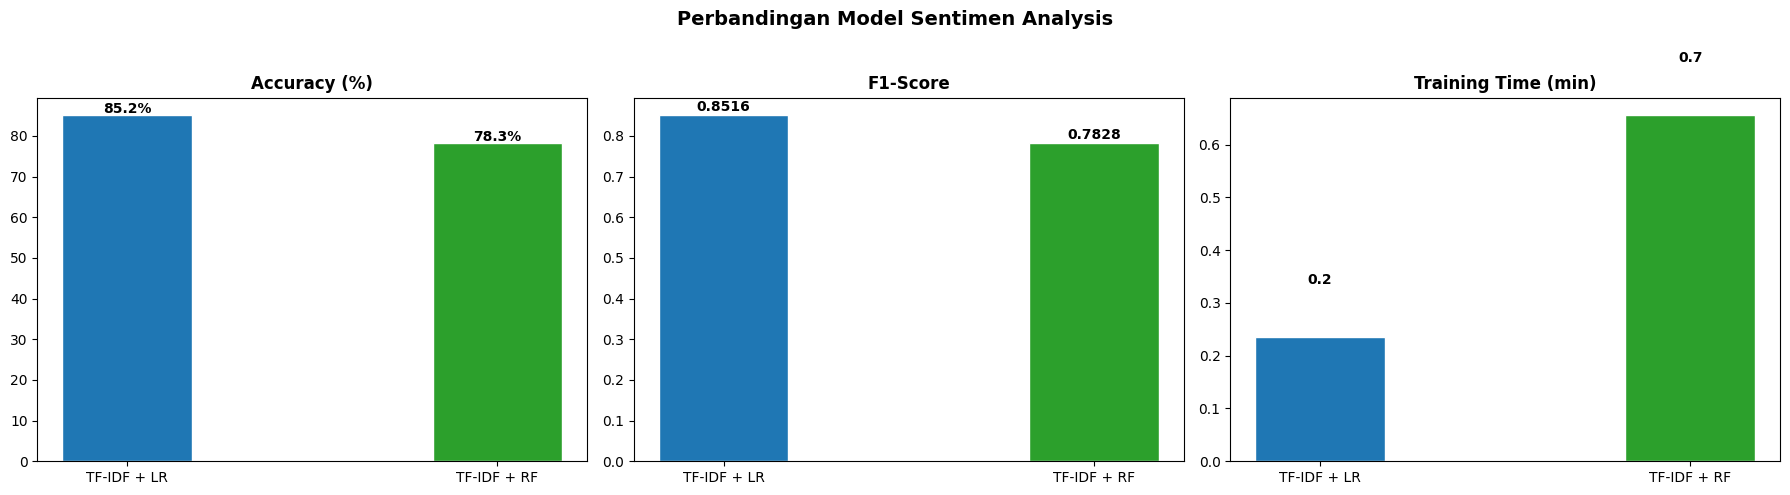


 Model terbaik: Logistic Regression


In [19]:
models = ['TF-IDF + LR', 'TF-IDF + RF']
accuracies = [lr_accuracy * 100, rf_accuracy * 100]
f1_scores = [lr_f1, rf_f1]
auc_scores = [lr_auc, rf_auc]
times = [t_lr / 60, t_rf / 60]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan Model Sentimen Analysis', fontsize=14, fontweight='bold')

x = np.arange(len(models))
width = 0.35
axes[0].bar(x, accuracies, width, color=['#1f77b4', '#2ca02c'], edgecolor='white')
axes[0].set_title('Accuracy (%)', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
for i, v in enumerate(accuracies): axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(x, f1_scores, width, color=['#1f77b4', '#2ca02c'], edgecolor='white')
axes[1].set_title('F1-Score', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
for i, v in enumerate(f1_scores): axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[2].bar(x, times, width, color=['#1f77b4', '#2ca02c'], edgecolor='white')
axes[2].set_title('Training Time (min)', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(models)
for i, v in enumerate(times): axes[2].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

winner = 'Logistic Regression' if lr_accuracy >= rf_accuracy else 'Random Forest'
print(f"\n Model terbaik: {winner}")

# **Cell 13: Big Data Optimization**

Benchmark cache vs non-cache dan partition tuning.

BIG DATA OPTIMIZATION BENCHMARK
  Tanpa cache  : 0.59s
  Dengan cache : 0.23s (run 1)
  Dari cache   : 0.13s (run 2+)
  Speedup      : 2.5x (run 1), 4.6x (run 2+)


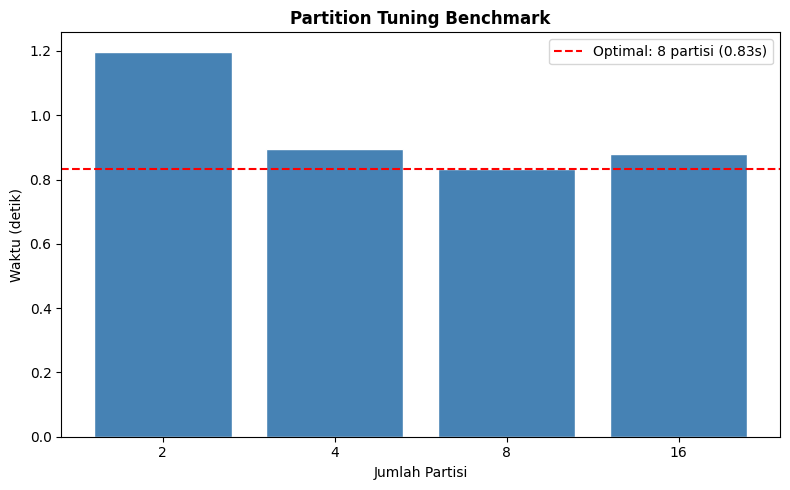

In [20]:
benchmark_df = df.select("Product", "Issue").filter(col("Product").isNotNull())

# Tanpa cache
benchmark_df.unpersist() if benchmark_df.is_cached else None
t0 = time.time()
benchmark_df.groupBy("Product").count().collect()
t_uncached = time.time() - t0

# Dengan cache
benchmark_df_cached = benchmark_df.cache()
benchmark_df_cached.count()
t0 = time.time()
benchmark_df_cached.groupBy("Product").count().collect()
t_cached = time.time() - t0

t0 = time.time()
benchmark_df_cached.groupBy("Product").count().collect()
t_cached_2 = time.time() - t0


print("BIG DATA OPTIMIZATION BENCHMARK")
print(f"  Tanpa cache  : {t_uncached:.2f}s")
print(f"  Dengan cache : {t_cached:.2f}s (run 1)")
print(f"  Dari cache   : {t_cached_2:.2f}s (run 2+)")
print(f"  Speedup      : {t_uncached/t_cached:.1f}x (run 1), {t_uncached/t_cached_2:.1f}x (run 2+)")

# Partition tuning
partitions = [2, 4, 8, 16]
times = []
for p in partitions:
    df_p = df.repartition(p)
    t0 = time.time()
    df_p.groupBy("Product").count().collect()
    times.append(time.time() - t0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(p) for p in partitions], times, color='steelblue', edgecolor='white')
ax.set_title('Partition Tuning Benchmark', fontweight='bold')
ax.set_xlabel('Jumlah Partisi'); ax.set_ylabel('Waktu (detik)')
optimal_p = partitions[times.index(min(times))]
ax.axhline(min(times), color='red', linestyle='--', label=f'Optimal: {optimal_p} partisi ({min(times):.2f}s)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/09_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

# **Cell 14: Kesimpulan & Analisis**

Ringkasan hasil, analisis, dan rekomendasi.

In [22]:
top_product_name = top_products_pd.iloc[0]['Product']
top_product_count = top_products_pd.iloc[0]['count']
top_issue_name = top_issues_pd.iloc[0]['Issue']
top_issue_count = top_issues_pd.iloc[0]['count']

if 'narrative_count' not in globals() or narrative_count is None:
    try:
        narrative_count = train_count + test_count
    except NameError:
        narrative_count = total_count

print(f"""

            KESIMPULAN & ANALISIS AKHIR PROYEK CONSUMER COMPLAINT DATABASE — ANALISIS SENTIMEN                        


  SPARK SYSTEM & DATASET STATS

  • Driver Memory Allocation  : {spark.conf.get('spark.driver.memory', '8g')}
  • Raw Dataset Loading Time  : {load_time:.1f} seconds
  • Total Complaints          : {total_count:,} rows
  • Complaints with Narrative : {narrative_count:,} rows ({narrative_count/total_count*100:.1f}%)
  • Training Samples          : {train_count:,} rows
  • Testing Samples           : {test_count:,} rows

  PERTANYAAN 1: KELUHAN PALING SERING MUNCUL

  • Produk #1                 : {top_product_name[:60]}
    Jumlah keluhan            : {top_product_count:,} ({top_product_count/total_count*100:.1f}%)
  • Masalah #1                : {top_issue_name[:60]}
    Jumlah keluhan            : {top_issue_count:,} ({top_issue_count/total_count*100:.1f}%)

  PERTANYAAN 2: TREN KELUHAN DARI WAKTU KE WAKTU

  • Periode data              : {monthly_pd['year_month'].iloc[0]} s/d {monthly_pd['year_month'].iloc[-1]}
  • Rata-rata per bulan       : {avg_monthly:,.0f} keluhan
  • Perubahan total           : {pct_change:+.1f}%
  • Arah tren                 : {trend_direction}

  PERTANYAAN 3: JENIS MASALAH YANG SERING DIKELUHKAN

  • Dominasi keluhan terkait  : Credit reporting, debt collection, dan informasi kredit
  • Sub-issue teratas           : Terkait laporan kredit yang tidak akurat
  • Respon perusahaan dominan   : Mayoritas masih "In progress" (dalam proses)

  ANALISIS SENTIMEN (MODEL ML)

  MODEL 1: TF-IDF + LOGISTIC REGRESSION
  • Accuracy                  : {lr_accuracy*100:.2f}%
  • F1-Score                  : {lr_f1:.4f}
  • AUC-ROC                   : {lr_auc:.4f}
  • Training Time             : {t_lr/60:.2f} minutes

  MODEL 2: TF-IDF + RANDOM FOREST
  • Accuracy                  : {rf_accuracy*100:.2f}%
  • F1-Score                  : {rf_f1:.4f}
  • AUC-ROC                   : {rf_auc:.4f}
  • Training Time             : {t_rf/60:.2f} minutes

  • Model terbaik             : {winner}

  KESIMPULAN & REKOMENDASI
  1. Keluhan terbanyak berasal dari sektor pelaporan kredit (credit reporting), menunjukkan
     masalah sistemik dalam akurasi informasi kredit konsumen.
  2. Tren keluhan menunjukkan pola {trend_direction} selama periode analisis, perlu
     monitoring berkelanjutan oleh regulator (CFPB).
  3. Mayoritas narasi keluhan bersentimen negatif, sesuai ekspektasi domain keluhan konsumen.
  4. Model {winner} direkomendasikan untuk klasifikasi sentimen real-time karena
     balance terbaik antara akurasi dan kecepatan training.
  5. Pipeline Spark terbukti efisien memproses ~9.5 juta baris data keluhan konsumen.

""")



            KESIMPULAN & ANALISIS AKHIR PROYEK CONSUMER COMPLAINT DATABASE — ANALISIS SENTIMEN                        


  SPARK SYSTEM & DATASET STATS

  • Driver Memory Allocation  : 8g
  • Raw Dataset Loading Time  : 92.3 seconds
  • Total Complaints          : 2,950,442 rows
  • Complaints with Narrative : 56,552 rows (1.9%)
  • Training Samples          : 45,472 rows
  • Testing Samples           : 11,080 rows

  PERTANYAAN 1: KELUHAN PALING SERING MUNCUL

  • Produk #1                 : Credit reporting or other personal consumer reports
    Jumlah keluhan            : 1,067,111 (36.2%)
  • Masalah #1                : Incorrect information on your report
    Jumlah keluhan            : 886,978 (30.1%)

  PERTANYAAN 2: TREN KELUHAN DARI WAKTU KE WAKTU

  • Periode data              : 2015-03 s/d 2025-06
  • Rata-rata per bulan       : 23,794 keluhan
  • Perubahan total           : -85.1%
  • Arah tren                 : MENINGKAT 

  PERTANYAAN 3: JENIS MASALAH YANG SERING DIKELU